In [25]:
import torch
import torch.nn.functional as F
import numpy as np
import timeit
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
from matplotlib import cm
import math


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dynamics:

The model is described as:
\begin{align}
    \begin{bmatrix}
        x\\
        y\\
        z
    \end{bmatrix}=\begin{bmatrix}
        x+yz\\
        y-xz\\
        -2z+x^2+y^2
    \end{bmatrix}
\end{align}

In [27]:
def checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    ball = Expression(0)
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt < 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )
    return CheckSatisfiability(logical_not(stability_condition), config)

# ---------------------------------------------------------------------
# Add counterexamples (unchanged)
# ---------------------------------------------------------------------
def AddCounterexamples(x, CE, N, device):
    # Detach x from the computational graph to avoid gradient issues
    x = x.detach()
    
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)

    for i in range(N):
        n_pt = [nearby[j][i] for j in range(x.shape[1])]
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x = torch.unique(x, dim=0)
    return x, n_pt_tensor

In [28]:

# ---------------------------------------------------------------------
# Network classes
# ---------------------------------------------------------------------
class polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        layers = []
        for _ in range(5):
            layers += [nn.Linear(hidden_dim if layers else input_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False
    def forward(self, x):
        return self.net(x)

class numerator_polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    def forward(self, x):
        return self.net(x)

class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)
        self.linear_layer.weight.requires_grad = False
    def forward(self, x):
        return abs(self.linear_layer.bias.expand(x.shape[0], 1))


In [29]:
def f(x):
    return torch.stack(
        [ x[...,0] + x[...,1]*x[...,2],
         x[...,1]-x[...,0]*x[...,2],
         -2* x[...,2]+x[...,0]**2 + x[...,1]**2
         ], dim=-1
    )

def g(x):
    return torch.zeros_like(x)

def div_f(x):
    return torch.zeros(x.shape[0], device=x.device)

def div_g(x):
    return torch.zeros(x.shape[0], device=x.device)

def control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    x.requires_grad_(True)
    f_vals = f_fun(x)
    g_vals = g_fun(x)
    divf_vals = div_f(x)
    divg_vals = div_g(x)

    a_vals = a_fun(x)
    c_vals = c_fun(x)
    b_vals = b_fun(x)

    # grad a, c (each batch × 2)
    grad_a = torch.autograd.grad(a_vals.sum(), x, create_graph=True)[0]
    grad_c = torch.autograd.grad(c_vals.sum(), x, create_graph=True)[0]

    # grad_b of ||b||²
    b_norm_sq = (b_vals ** 2).sum(dim=1)
    grad_b = torch.autograd.grad(b_norm_sq.sum(), x, create_graph=True)[0]

    term1 = a_vals.squeeze() * divf_vals + divg_vals * c_vals.squeeze() \
            + (grad_a * f_vals).sum(dim=1) + (grad_c * g_vals).sum(dim=1)
    term2 = ((2*x + grad_b) * (f_vals * a_vals + g_vals * c_vals)).sum(dim=1)
    return term1 - term2

def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun):
    divergence = control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    loss = F.relu(divergence).mean()
    a_loss = F.relu(-a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_fun(x)).mean()
    return loss + a_loss + gamma_loss

In [30]:
class activSymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            # z = [tanh(zi) for zi in z]
            # Apply sigmoid activation
            z = [(1/(1 + exp(-zi))) for zi in z]
        
        # # Final linear layer without activation
        # z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [31]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
            # # Apply sigmoid activation
            # z = [(1/(1 + exp(-zi))) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [32]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]

    b_sym = sum([bi**2 for bi in b_sym])
    f_val = [vars[0]+vars[1]*vars[2],vars[1]-vars[0]*vars[2],-2*vars[2]+vars[0]**2+vars[1]**2]
    g_val = [0*vars[0],0*vars[0],0*vars[0]]
    # print("g_val: ", g_val)
    f_div = 0
    g_div = 0 
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))] 
    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]

    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])  
    constraint = constraint1 - constraint2
    return a_sym , constraint       

In [33]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [34]:
def train_density(x,epochs=200,iteration=500,lr=1e-4):
    loss_total_density = []
    a_net = numerator_polynomial_net(3, 1, 1).to(device)
    c_net = polynomial_net(3, 1, 1).to(device)
    b_net = polynomial_net_bias_Zero(3, 2, 2).to(device)
    gamma_net = GammaFunctionNet(3, 1).to(device)

    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), lr=lr
    )

    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5
    epsilon = 0
    ball_lb, ball_ub = 0.5, 6

    valid = False
    while not valid:
        for epoch in range(epochs):
            for iter in range(iteration):
                optimizer.zero_grad()
                loss = control_density_loss(x,f,g,a_net,b_net,c_net,gamma_net)
                loss_total_density.append(loss.item())
                loss.backward()
                optimizer.step()

            if loss.item() < 1e-4:
                valid = True
                print("Threshold Reached.")
                break

            if epoch % 1 == 0:
                print(f"Epoch {epoch}, Loss: {loss.item()}")
            
            if epoch % 10 == 0:
                vars = [Variable("x1"), Variable("x2"), Variable("x3")]
                a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config, epsilon)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break
    return a_net, b_net, c_net, gamma_net, loss_total_density

def plot_results(risks, labels):
    plt.figure(figsize=(10,6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.legend()
    plt.grid()
    plt.show()


In [35]:

torch.cuda.empty_cache()
torch.manual_seed(42)
random.seed()

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
numerical_x = torch.Tensor(500, 3).uniform_(-6, 6).float().to(device)


Using device: cpu


In [36]:
# ---------------------------------------------------------------------
# Run training
# ---------------------------------------------------------------------
a_ret, b_ret, c_ret, gamma_net,loss_density = train_density(numerical_x, epochs=4000, lr=1e-2)

Epoch 0, Loss: 1.7645649909973145
Counterexample found!
Epoch 1, Loss: 0.40209436416625977
Epoch 2, Loss: 0.13807553052902222
Epoch 3, Loss: 0.0716652050614357
Epoch 4, Loss: 0.04316139221191406
Epoch 5, Loss: 0.028750000521540642
Epoch 6, Loss: 0.020049626007676125
Epoch 7, Loss: 0.014367650263011456
Epoch 8, Loss: 0.010546963661909103
Epoch 9, Loss: 0.007881492376327515
Epoch 10, Loss: 0.005963848438113928
Counterexample found!
Epoch 11, Loss: 0.004006699193269014
Epoch 12, Loss: 0.0031402050517499447
Epoch 13, Loss: 0.0024645577650517225
Epoch 14, Loss: 0.0019249265315011144
Epoch 15, Loss: 0.0015083466423675418
Epoch 16, Loss: 0.001179610611870885
Epoch 17, Loss: 0.0009212807053700089
Epoch 18, Loss: 0.0007273309747688472
Epoch 19, Loss: 0.000560066313482821
Epoch 20, Loss: 0.0004376496945042163
Counterexample found!
Epoch 21, Loss: 0.00030756863998249173
Epoch 22, Loss: 0.00024467174080200493
Epoch 23, Loss: 0.00019455399888101965
Epoch 24, Loss: 0.00015297297795768827
Epoch 25, L

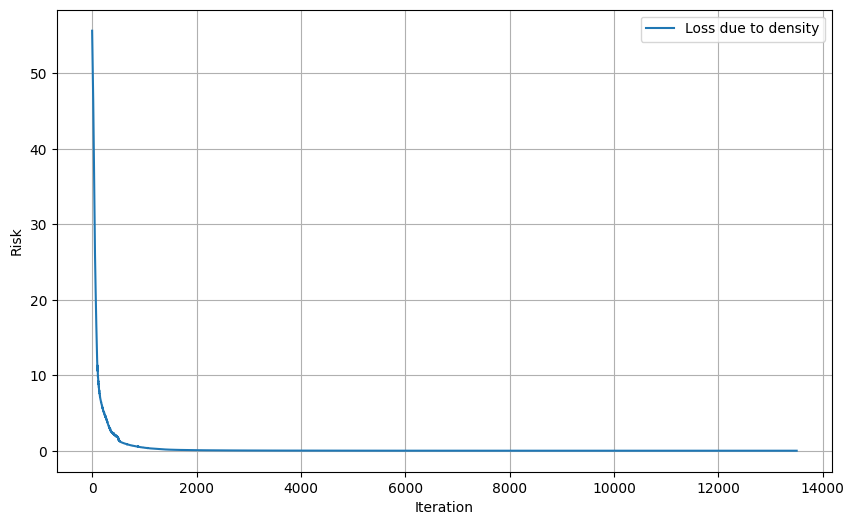

In [37]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


/tmp/ipykernel_212881/3726211260.py:59: RuntimeWarning: overflow encountered in exp
  rho_vals =(1e+9)* a_vals / np.exp(x_norm_sq + b_norm_sq)


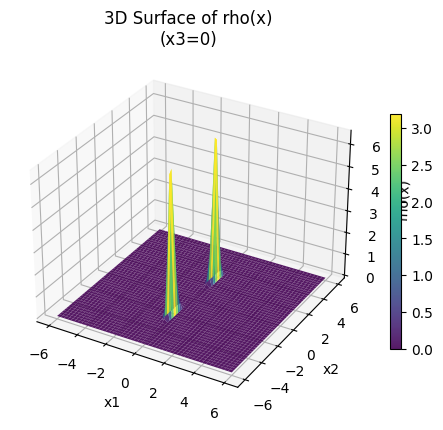

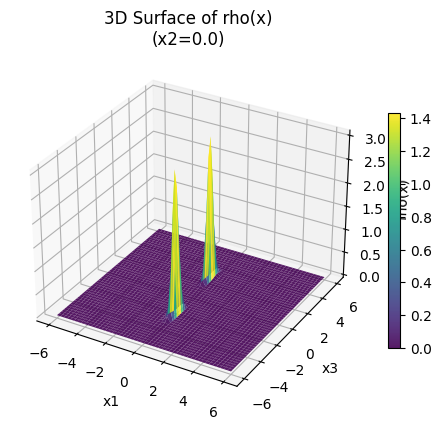

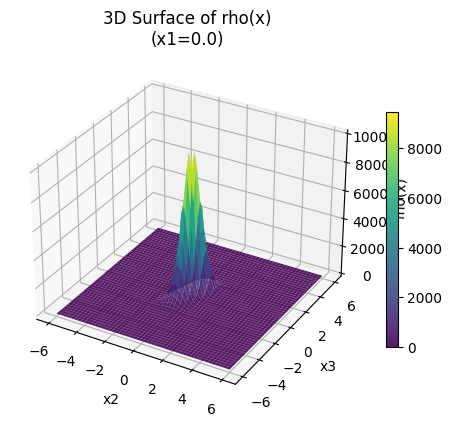

(array([[4.97656205e-28, 8.91432776e-27, 1.41596255e-25, ...,
         1.60153025e-25, 1.01472650e-26, 5.70207190e-28],
        [8.63176841e-27, 1.54993221e-25, 2.46773204e-24, ...,
         2.83789733e-24, 1.79616528e-25, 1.00819890e-26],
        [1.31392709e-25, 2.36753684e-24, 3.78197304e-23, ...,
         4.40945541e-23, 2.78551953e-24, 1.56044317e-25],
        ...,
        [1.56054424e-25, 2.78569998e-24, 4.40974950e-23, ...,
         3.78262969e-23, 2.36795198e-24, 1.31416153e-25],
        [1.00827016e-26, 1.79629224e-25, 2.83810322e-24, ...,
         2.46817676e-24, 1.55021744e-25, 8.63337464e-27],
        [5.70250090e-28, 1.01480284e-26, 1.60165536e-25, ...,
         1.41622990e-25, 8.91603644e-27, 4.97753031e-28]], dtype=float32),
 array([[-6.        , -5.75510204, -5.51020408, ...,  5.51020408,
          5.75510204,  6.        ],
        [-6.        , -5.75510204, -5.51020408, ...,  5.51020408,
          5.75510204,  6.        ],
        [-6.        , -5.75510204, -5.51020408

In [41]:
def visualize_rho(a_net, b_net, num_points=50, fixed_values=None, device='cpu'):
    """
    Visualize the surface of rho = a(x) / exp(||x||^2 + ||b(x)||^2)
    
    Args:
        a_net: Trained network for a(x)
        b_net: Trained network for b(x)
        num_points: Number of points along each axis
        fixed_values: Dict specifying which variable to fix and at what value
                     e.g., {'x3': 0.0} to plot x1-x2 plane at x3=0
        device: torch device
    """
    a_net.eval()
    b_net.eval()
    
    # Define the range for visualization
    coord_range = np.linspace(-6, 6, num_points)
    
    # Default: fix x3 and plot x1-x2
    if fixed_values is None:
        fixed_values = {'x3': 0.0}
    
    # Determine which variables are free
    all_vars = ['x1', 'x2', 'x3']
    fixed_var = list(fixed_values.keys())[0]
    free_vars = [v for v in all_vars if v not in fixed_values]
    
    if len(free_vars) != 2:
        raise ValueError("Must fix exactly one variable for 2D visualization")
    
    # Create meshgrid for the two free variables
    V1, V2 = np.meshgrid(coord_range, coord_range)
    
    # Prepare input tensor
    X_vis = torch.zeros((num_points * num_points, 3), device=device)
    
    # Map variables to indices
    var_to_idx = {'x1': 0, 'x2': 1, 'x3': 2}
    
    # Fill in the free variables
    X_vis[:, var_to_idx[free_vars[0]]] = torch.from_numpy(V1.flatten()).float()
    X_vis[:, var_to_idx[free_vars[1]]] = torch.from_numpy(V2.flatten()).float()
    
    # Fill in the fixed variable
    X_vis[:, var_to_idx[fixed_var]] = fixed_values[fixed_var]
    
    with torch.no_grad():
        # Compute a(x)
        a_vals = a_net(X_vis).cpu().numpy().flatten()
        
        # Compute b(x)
        b_vals = b_net(X_vis).cpu().numpy()
        b_norm_sq = np.sum(b_vals**2, axis=1)
        
        # Compute ||x||^2
        x_norm_sq = torch.sum(X_vis**2, dim=1).cpu().numpy()
        
        # Compute rho
        rho_vals =(1e+9)* a_vals / np.exp(x_norm_sq + b_norm_sq)
        rho_vals = rho_vals.reshape(num_points, num_points)
    
    # Create the plot
    fig = plt.figure(figsize=(14, 5))
    
    # 3D surface plot
    ax1 = fig.add_subplot(131, projection='3d')
    surf = ax1.plot_surface(V1, V2, rho_vals, cmap=cm.viridis, 
                            linewidth=0, antialiased=True, alpha=0.9)
    ax1.set_xlabel(free_vars[0])
    ax1.set_ylabel(free_vars[1])
    ax1.set_zlabel('rho(x)')
    ax1.set_title(f'3D Surface of rho(x)\n({fixed_var}={fixed_values[fixed_var]})')
    fig.colorbar(surf, ax=ax1, shrink=0.5)
    
    # # 2D contour plot
    # ax2 = fig.add_subplot(132)
    # contour = ax2.contourf(V1, V2, rho_vals, levels=20, cmap=cm.viridis)
    # ax2.contour(V1, V2, rho_vals, levels=20, colors='black', 
    #             linewidths=0.5, alpha=0.3)
    # ax2.set_xlabel(free_vars[0])
    # ax2.set_ylabel(free_vars[1])
    # ax2.set_title(f'Contour Plot of rho(x)\n({fixed_var}={fixed_values[fixed_var]})')
    # fig.colorbar(contour, ax=ax2)
    
    # # 2D heatmap
    # ax3 = fig.add_subplot(133)
    # heatmap = ax3.imshow(rho_vals, extent=[-6, 6, -6, 6], 
    #                      origin='lower', cmap=cm.viridis, aspect='auto')
    # ax3.set_xlabel(free_vars[0])
    # ax3.set_ylabel(free_vars[1])
    # ax3.set_title(f'Heatmap of rho(x)\n({fixed_var}={fixed_values[fixed_var]})')
    # fig.colorbar(heatmap, ax=ax3)
    
    plt.tight_layout()
    plt.show()
    
    
    return rho_vals, V1, V2


# def visualize_rho_multiple_slices(a_net, b_net, num_points=50, device='cpu'):
#     """
#     Visualize rho across multiple slices of the 3D space
#     """
#     fig = plt.figure(figsize=(18, 12))
    
#     # Different slices to visualize
#     slices = [
#         {'x3': 0.0},
#         {'x3': 2.0},
#         {'x3': -2.0},
#         {'x2': 0.0},
#         {'x2': 2.0},
#         {'x2': -2.0},
#         {'x1': 0.0},
#         {'x1': 2.0},
#         {'x1': -2.0},
#     ]
    
#     coord_range = np.linspace(-6, 6, num_points)
    
#     for idx, fixed_vals in enumerate(slices):
#         a_net.eval()
#         b_net.eval()
        
#         all_vars = ['x1', 'x2', 'x3']
#         fixed_var = list(fixed_vals.keys())[0]
#         free_vars = [v for v in all_vars if v not in fixed_vals]
        
#         V1, V2 = np.meshgrid(coord_range, coord_range)
#         X_vis = torch.zeros((num_points * num_points, 3), device=device)
        
#         var_to_idx = {'x1': 0, 'x2': 1, 'x3': 2}
#         X_vis[:, var_to_idx[free_vars[0]]] = torch.from_numpy(V1.flatten()).float()
#         X_vis[:, var_to_idx[free_vars[1]]] = torch.from_numpy(V2.flatten()).float()
#         X_vis[:, var_to_idx[fixed_var]] = fixed_vals[fixed_var]
        
#         with torch.no_grad():
#             a_vals = a_net(X_vis).cpu().numpy().flatten()
#             b_vals = b_net(X_vis).cpu().numpy()
#             b_norm_sq = np.sum(b_vals**2, axis=1)
#             x_norm_sq = torch.sum(X_vis**2, dim=1).cpu().numpy()
#             rho_vals = a_vals / np.exp(x_norm_sq + b_norm_sq)
#             rho_vals = rho_vals.reshape(num_points, num_points)
        
#         ax = fig.add_subplot(3, 3, idx + 1)
#         contour = ax.contourf(V1, V2, rho_vals, levels=15, cmap=cm.viridis)
#         ax.set_xlabel(free_vars[0])
#         ax.set_ylabel(free_vars[1])
#         ax.set_title(f'{fixed_var}={fixed_vals[fixed_var]}')
#         plt.colorbar(contour, ax=ax)
    
#     plt.suptitle('ρ(x) across different slices', fontsize=16, y=0.995)
#     plt.tight_layout()
#     plt.show()


# Usage after training:
# Visualize single slice
# visualize_rho(a_ret, b_ret, num_points=50, fixed_values={'x3': 0.0}, device=device)

# Visualize at different x3 values
visualize_rho(a_ret, b_ret, fixed_values={'x3': 0}, device=device)
# visualize_rho(a_ret, b_ret, fixed_values={'x3': -1.0}, device=device)

# Visualize fixing x2 instead
visualize_rho(a_ret, b_ret, fixed_values={'x2': 0.0}, device=device)
# visualize_rho(a_ret, b_ret, fixed_values={'x2': 1.0}, device=device)

# Visualize fixing x2 instead
visualize_rho(a_ret, b_ret, fixed_values={'x1': 0.0}, device=device)
# visualize_rho(a_ret, b_ret, fixed_values={'x1': 1.0}, device=device)

# # Visualize multiple slices at once
# visualize_rho_multiple_slices(a_ret, b_ret, num_points=50, device=device)

In [39]:

import phaseportrait
from phaseportrait.streamlines import *

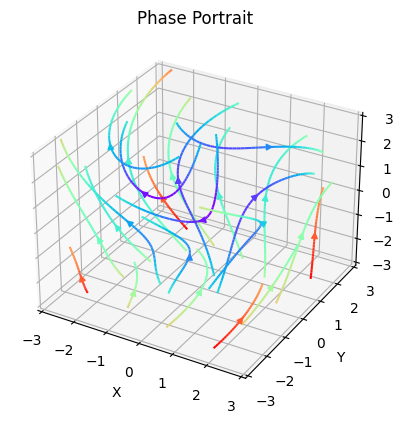

In [40]:
def dF(x,y,z):
    return (x+y*z), (y-x*z), (-2*z+x**2+y**2)

p1 = phaseportrait.PhasePortrait3D(dF, [-3, 3], MeshDim=5, maxLen=3000, deltat=0.05)
p1.plot()
plt.show()
